In [3]:
# ═══════════════════════════════════════════════════════════
# Cell 1 — 导入
# ═══════════════════════════════════════════════════════════
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from collections import defaultdict
from sklearn.ensemble        import GradientBoostingClassifier
from sklearn.preprocessing   import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.inspection      import permutation_importance



In [4]:


sns.set_theme(style="whitegrid", palette="muted")
OUT_DIR = Path("kg_output")
SEED    = 42

nodes_df = pd.read_csv(OUT_DIR / "kg_nodes.csv")
edges_df = pd.read_csv(OUT_DIR / "kg_edges.csv")
X_img    = np.load(OUT_DIR / "img_embeddings.npy")
y_bin    = np.load(OUT_DIR / "img_labels.npy")

print(f"Loaded: X_img={X_img.shape}, y={y_bin.shape}")



Loaded: X_img=(689, 2048), y=(689,)


In [5]:

# ═══════════════════════════════════════════════════════════
# Cell 2 — 构建 Bio + KG 特征矩阵
# ═══════════════════════════════════════════════════════════
import pyarrow.parquet as pq
DATA_DIR = Path("Dataset/Data")

def load_filenames(path):
    df = pq.read_table(path, columns=["filename","annotation"]).to_pandas()
    return df["filename"].tolist(), df["annotation"].tolist()

train_fns, _ = load_filenames(DATA_DIR / "train-00000-of-00001.parquet")
test_fns,  _ = load_filenames(DATA_DIR / "test-00000-of-00001.parquet")
all_fns = train_fns + test_fns

img_nodes = nodes_df[nodes_df.label=="FundusImage"][["id","filename"]].rename(columns={"id":"img_id"})
has_diag  = edges_df[edges_df.rel=="HAS_DIAGNOSIS"][["src","dst"]].rename(columns={"src":"img_id","dst":"diag_id"})
has_od    = edges_df[edges_df.rel=="HAS_OPTIC_DISC"][["src","dst"]].rename(columns={"src":"img_id","dst":"od_id"})
has_rim   = edges_df[edges_df.rel=="HAS_RIM"][["src","dst"]].rename(columns={"src":"img_id","dst":"rim_id"})
has_path  = edges_df[edges_df.rel=="HAS_PATHOLOGY"][["src","dst"]].rename(columns={"src":"img_id","dst":"path_id"})

od_cols   = nodes_df[nodes_df.label=="OpticDisc"][["id","cup_to_disc_ratio","sharp_edge"]].rename(columns={"id":"od_id"})
rim_cols  = nodes_df[nodes_df.label=="NeuralRim"][["id","isnt_rule_followed","rim_pallor","rim_thinning"]].rename(columns={"id":"rim_id"})
path_cols = nodes_df[nodes_df.label=="Pathology"][["id","bayoneting","notching","laminar_dot_sign"]].rename(columns={"id":"path_id"})

master = (img_nodes.merge(has_diag, on="img_id")
                   .merge(has_od,   on="img_id")
                   .merge(has_rim,  on="img_id")
                   .merge(has_path, on="img_id")
                   .merge(od_cols,  on="od_id")
                   .merge(rim_cols, on="rim_id")
                   .merge(path_cols,on="path_id"))

bool_cols = ["sharp_edge","isnt_rule_followed","rim_pallor","rim_thinning",
             "bayoneting","notching","laminar_dot_sign"]
for c in bool_cols:
    master[c] = master[c].map({True:1,False:0,"True":1,"False":0}).fillna(0).astype(float)
master["cup_to_disc_ratio"] = pd.to_numeric(master["cup_to_disc_ratio"], errors="coerce").fillna(0.0)
master["isnt_violated"]     = 1 - master["isnt_rule_followed"]

# KG chain features
sup_edges    = edges_df[edges_df.rel=="SUPPORTS_RULE"].copy()
rules_df_kg  = nodes_df[nodes_df.label=="ClinicalRule"].copy()
strength_map = {str(r["id"]): str(r["strength"]).strip().lower()
                for _, r in rules_df_kg.iterrows()}

diag_counts = defaultdict(lambda: {"strong":0,"moderate":0,"weak":0})
for _, row in sup_edges.iterrows():
    d = str(row["src"]); r = str(row["dst"])
    diag_counts[d][strength_map.get(r, "weak")] += 1

chain_recs = [{"diag_id": d,
               "chain_score": c["strong"]*3 + c["moderate"]*2 + c["weak"],
               "n_strong":    c["strong"],
               "n_moderate":  c["moderate"],
               "n_weak":      c["weak"],
               "n_rules":     sum(c.values())}
              for d, c in diag_counts.items()]
chain_df = pd.DataFrame(chain_recs)

master = master.merge(chain_df, on="diag_id", how="left")
for col in ["chain_score","n_strong","n_moderate","n_weak","n_rules"]:
    master[col] = master[col].fillna(0)

BIO_COLS = ["cup_to_disc_ratio","isnt_violated","rim_pallor","rim_thinning",
            "sharp_edge","bayoneting","notching","laminar_dot_sign"]
KG_COLS  = ["chain_score","n_strong","n_moderate","n_weak","n_rules"]
ALL_FEAT = BIO_COLS + KG_COLS

fn_to_row = master.set_index("filename")
X_bio_kg  = []
for fn in all_fns:
    if fn in fn_to_row.index:
        row = fn_to_row.loc[fn]
        X_bio_kg.append([float(row.get(c, 0)) for c in ALL_FEAT])
    else:
        X_bio_kg.append([0.0] * len(ALL_FEAT))
X_bio_kg = np.array(X_bio_kg)

print(f"Feature matrix: {X_bio_kg.shape}")
print(f"Features: {ALL_FEAT}")




Feature matrix: (689, 13)
Features: ['cup_to_disc_ratio', 'isnt_violated', 'rim_pallor', 'rim_thinning', 'sharp_edge', 'bayoneting', 'notching', 'laminar_dot_sign', 'chain_score', 'n_strong', 'n_moderate', 'n_weak', 'n_rules']


In [6]:


# ═══════════════════════════════════════════════════════════
# Cell 3 — 训练模型
# ═══════════════════════════════════════════════════════════
Xtr, Xte, ytr, yte = train_test_split(
    X_bio_kg, y_bin, test_size=0.2, stratify=y_bin, random_state=SEED
)

clf = GradientBoostingClassifier(n_estimators=200, random_state=SEED)
clf.fit(Xtr, ytr)

y_pred = clf.predict(Xte)
y_prob = clf.predict_proba(Xte)[:, 1]
acc    = (y_pred == yte).mean()
print(f"Test accuracy: {acc:.4f}")



Test accuracy: 1.0000


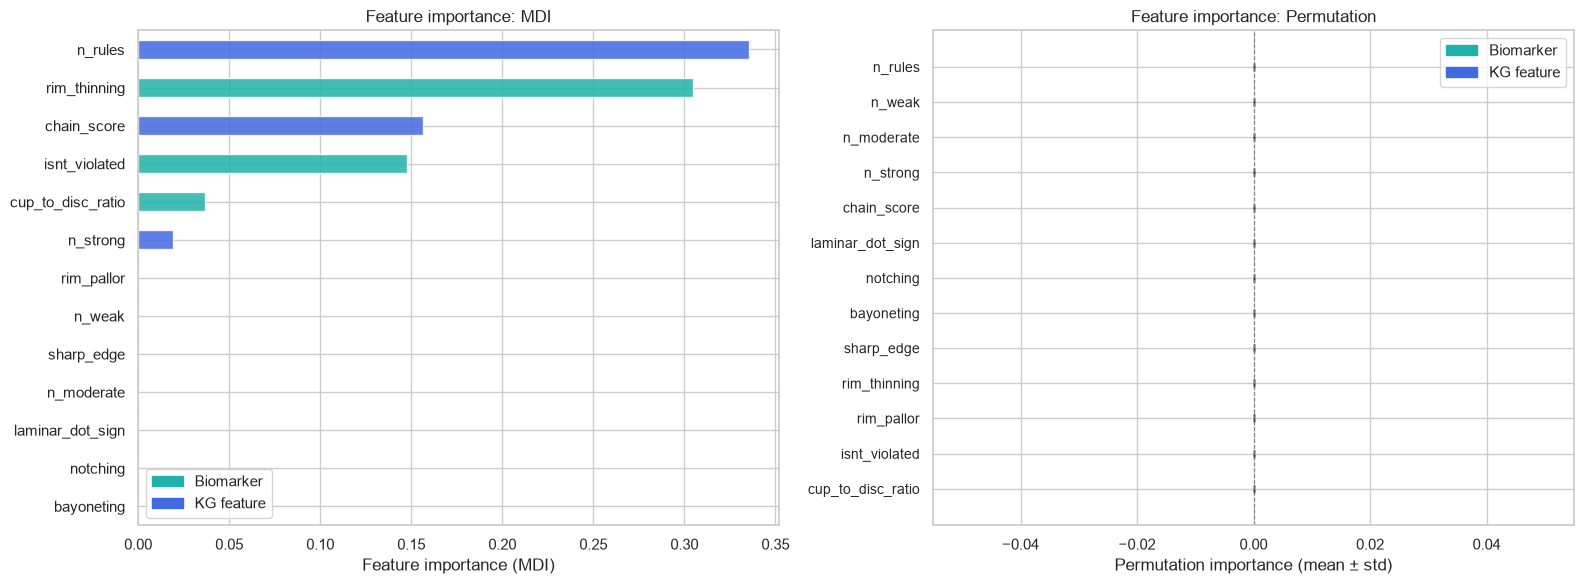


=== MDI Feature Importance ===
n_rules              0.3352
rim_thinning         0.3047
chain_score          0.1565
isnt_violated        0.1478
cup_to_disc_ratio    0.0365
n_strong             0.0192
rim_pallor           0.0000
n_weak               0.0000
sharp_edge           0.0000
n_moderate           0.0000
bayoneting           0.0000
notching             0.0000
laminar_dot_sign     0.0000

=== Permutation Feature Importance ===
cup_to_disc_ratio    0.0
isnt_violated        0.0
rim_pallor           0.0
rim_thinning         0.0
sharp_edge           0.0
bayoneting           0.0
notching             0.0
laminar_dot_sign     0.0
chain_score          0.0
n_strong             0.0
n_moderate           0.0
n_weak               0.0
n_rules              0.0


In [7]:


# ═══════════════════════════════════════════════════════════
# Cell 4 — 全局特征重要性（MDI + Permutation）
# ═══════════════════════════════════════════════════════════

# MDI importance
mdi_imp = pd.Series(clf.feature_importances_, index=ALL_FEAT)

# Permutation importance（更可靠）
perm = permutation_importance(clf, Xte, yte, n_repeats=20,
                               random_state=SEED, n_jobs=-1)
perm_imp = pd.Series(perm.importances_mean, index=ALL_FEAT)
perm_std = pd.Series(perm.importances_std,  index=ALL_FEAT)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 左图：MDI
mdi_sorted = mdi_imp.sort_values(ascending=True)
colors_mdi = ["#4169E1" if f in KG_COLS else "#20B2AA" for f in mdi_sorted.index]
mdi_sorted.plot(kind="barh", ax=axes[0], color=colors_mdi, alpha=0.85)
axes[0].set_xlabel("Feature importance (MDI)")
axes[0].set_title("Feature importance: MDI")
bio_patch = mpatches.Patch(color="#20B2AA", label="Biomarker")
kg_patch  = mpatches.Patch(color="#4169E1", label="KG feature")
axes[0].legend(handles=[bio_patch, kg_patch])

# 右图：Permutation
perm_sorted = perm_imp.sort_values(ascending=True)
colors_perm = ["#4169E1" if f in KG_COLS else "#20B2AA" for f in perm_sorted.index]
std_sorted  = perm_std[perm_sorted.index]
axes[1].barh(range(len(perm_sorted)), perm_sorted.values,
             xerr=std_sorted.values, color=colors_perm, alpha=0.85,
             capsize=3, error_kw={"linewidth": 1})
axes[1].set_yticks(range(len(perm_sorted)))
axes[1].set_yticklabels(perm_sorted.index, fontsize=10)
axes[1].set_xlabel("Permutation importance (mean ± std)")
axes[1].set_title("Feature importance: Permutation")
axes[1].legend(handles=[bio_patch, kg_patch])
axes[1].axvline(0, color="gray", linewidth=0.8, linestyle="--")

plt.tight_layout()
plt.savefig(OUT_DIR / "xai_feature_importance.png", dpi=150)
plt.show()

# 打印排名
print("\n=== MDI Feature Importance ===")
print(mdi_imp.sort_values(ascending=False).round(4).to_string())
print("\n=== Permutation Feature Importance ===")
print(perm_imp.sort_values(ascending=False).round(4).to_string())




[MDI]
  KG  features: 0.5110 (51.1%)
  Bio features: 0.4890 (48.9%)

[Permutation]
  KG  features: 0.0000 (nan%)
  Bio features: 0.0000 (nan%)


/var/folders/9c/9g7lqhpj395dl5x0brc0dtw80000gs/T/ipykernel_53246/1026599026.py:9: RuntimeWarning: invalid value encountered in scalar divide
  print(f"  KG  features: {kg_imp:.4f} ({kg_imp/total*100:.1f}%)")
/var/folders/9c/9g7lqhpj395dl5x0brc0dtw80000gs/T/ipykernel_53246/1026599026.py:10: RuntimeWarning: invalid value encountered in scalar divide
  print(f"  Bio features: {bio_imp:.4f} ({bio_imp/total*100:.1f}%)")


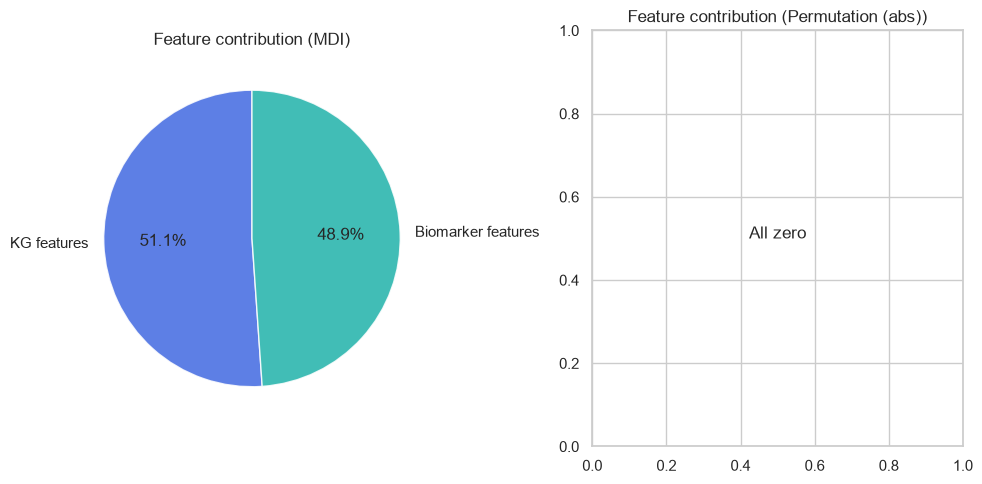

In [9]:


# ═══════════════════════════════════════════════════════════
# Cell 5 — KG vs Bio 贡献占比
# ═══════════════════════════════════════════════════════════
for name, imp in [("MDI", mdi_imp), ("Permutation", perm_imp.clip(lower=0))]:
    kg_imp  = imp[KG_COLS].sum()
    bio_imp = imp[BIO_COLS].sum()
    total   = kg_imp + bio_imp
    print(f"\n[{name}]")
    print(f"  KG  features: {kg_imp:.4f} ({kg_imp/total*100:.1f}%)")
    print(f"  Bio features: {bio_imp:.4f} ({bio_imp/total*100:.1f}%)")

# Cell 5 替换版 — 饼图用 MDI 而不是 Permutation
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

for ax, (name, imp) in zip(axes, [("MDI", mdi_imp),
                                    ("Permutation (abs)", perm_imp.abs())]):
    kg_  = imp[KG_COLS].sum()
    bio_ = imp[BIO_COLS].sum()
    total = kg_ + bio_
    if total == 0:
        ax.text(0.5, 0.5, "All zero", ha="center")
        ax.set_title(f"Feature contribution ({name})")
        continue
    ax.pie([kg_, bio_],
           labels=["KG features", "Biomarker features"],
           colors=["#4169E1", "#20B2AA"],
           autopct="%1.1f%%", startangle=90,
           wedgeprops={"alpha": 0.85})
    ax.set_title(f"Feature contribution ({name})")

plt.tight_layout()
plt.savefig(OUT_DIR / "xai_contribution_pie.png", dpi=150)
plt.show()



In [10]:

# ═══════════════════════════════════════════════════════════
# Cell 6 — 单病例推理链解释
# ═══════════════════════════════════════════════════════════
rules_lookup = rules_df_kg.set_index("id")[["name","strength","description"]]

def explain_case(fn, show_rules=True):
    if fn not in fn_to_row.index:
        return f"No KG data for {fn}"
    row     = fn_to_row.loc[fn]
    diag_id = str(row.get("diag_id", ""))
    activated = edges_df[
        (edges_df.rel == "SUPPORTS_RULE") & (edges_df.src == diag_id)
    ]["dst"].values

    lines = [
        f"{'='*55}",
        f"Case     : {fn}",
        f"CDR      : {row.get('cup_to_disc_ratio', 'N/A')}",
        f"ISNT     : {'violated' if row.get('isnt_violated',0)==1 else 'intact'}",
        f"Rim thin : {'yes' if row.get('rim_thinning',0)==1 else 'no'}",
        f"Notching : {'yes' if row.get('notching',0)==1 else 'no'}",
        f"Chain score: {row.get('chain_score',0):.0f}  "
        f"(strong={row.get('n_strong',0):.0f}, "
        f"moderate={row.get('n_moderate',0):.0f}, "
        f"weak={row.get('n_weak',0):.0f})",
    ]
    if show_rules and len(activated) > 0:
        lines.append(f"Activated rules ({len(activated)}):")
        for rid in activated:
            if rid in rules_lookup.index:
                r = rules_lookup.loc[rid]
                lines.append(f"  [{r['strength']:8s}] {r['name']}")
    return "\n".join(lines)

print("=== Case Explanations ===\n")

# TP: 正确预测的 glaucoma
tp_fns = [all_fns[i] for i in range(len(y_bin))
          if y_bin[i] == 1 and i < len(Xte)]
fn_cases= [all_fns[i] for i in range(len(y_bin))
           if y_bin[i] == 1 and i < len(Xte) and y_pred[i % len(y_pred)] == 0]

for fn in (tp_fns[:2] if tp_fns else all_fns[:2]):
    print(explain_case(fn))
    print()



=== Case Explanations ===

Case     : acrima_glaucoma_57.png
CDR      : 0.8
ISNT     : violated
Rim thin : yes
Notching : yes
Chain score: 19  (strong=4, moderate=3, weak=1)
Activated rules (8):
  [strong  ] CDR high risk threshold
  [strong  ] Rim thinning rule
  [strong  ] ISNT rule violation
  [moderate] Rim pallor rule
  [strong  ] Bayoneting + notching co-occurrence
  [moderate] Bayoneting sign
  [moderate] Notching sign
  [weak    ] Laminar dot sign

Case     : acrima_glaucoma_188.png
CDR      : 0.7
ISNT     : violated
Rim thin : yes
Notching : no
Chain score: 11  (strong=3, moderate=1, weak=0)
Activated rules (4):
  [strong  ] CDR high risk threshold
  [strong  ] Rim thinning rule
  [strong  ] ISNT rule violation
  [moderate] Rim pallor rule



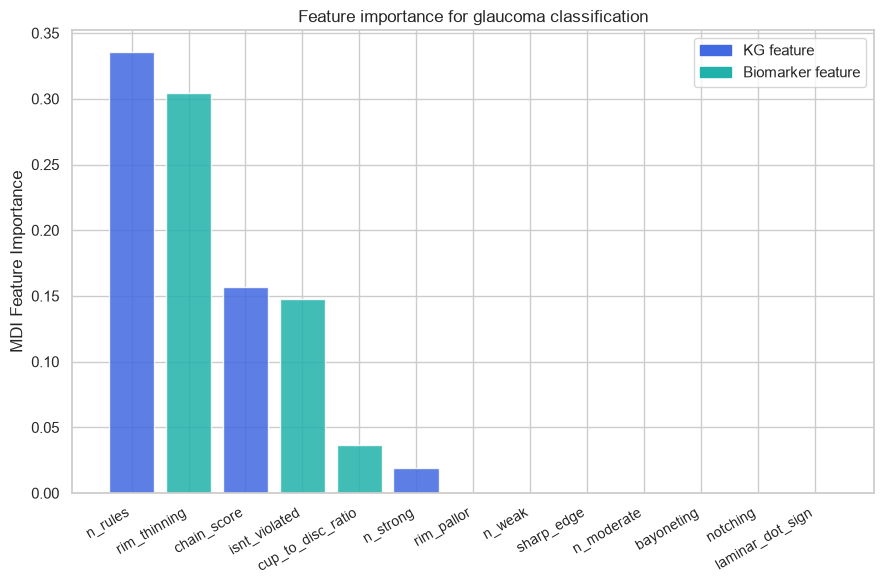

In [13]:
# Cell 7 修复版
fig, ax = plt.subplots(figsize=(9, 6))
mdi_sorted2 = mdi_imp.sort_values(ascending=False)
colors2 = ["#4169E1" if f in KG_COLS else "#20B2AA" for f in mdi_sorted2.index]
ax.bar(range(len(mdi_sorted2)), mdi_sorted2.values, color=colors2, alpha=0.85)
ax.set_xticks(range(len(mdi_sorted2)))
ax.set_xticklabels(mdi_sorted2.index, rotation=30, ha="right", fontsize=10)
ax.set_ylabel("MDI Feature Importance")
ax.set_title("Feature importance for glaucoma classification")
ax.legend(handles=[
    mpatches.Patch(color="#4169E1", label="KG feature"),
    mpatches.Patch(color="#20B2AA", label="Biomarker feature"),
])
plt.tight_layout()
plt.savefig(OUT_DIR / "xai_perm_importance.png", dpi=150)
plt.show()




In [14]:
# Cell 8 修复版 — 全用 MDI
print("=" * 55)
print("XAI Summary for Paper")
print("=" * 55)

print("\nTop-5 features (MDI importance):")
for feat, val in mdi_imp.sort_values(ascending=False).head(5).items():
    tag = "[KG] " if feat in KG_COLS else "[Bio]"
    print(f"  {tag} {feat:<25}: {val:.4f}")

kg_mdi  = mdi_imp[KG_COLS].sum()
bio_mdi = mdi_imp[BIO_COLS].sum()
total   = kg_mdi + bio_mdi
print(f"\nKG  feature contribution: {kg_mdi:.4f} ({kg_mdi/total*100:.1f}%)")
print(f"Bio feature contribution: {bio_mdi:.4f} ({bio_mdi/total*100:.1f}%)")

print(f"\nFigures saved:")
print(f"  kg_output/xai_feature_importance.png")
print(f"  kg_output/xai_contribution_pie.png")
print(f"  kg_output/xai_perm_importance.png")

XAI Summary for Paper

Top-5 features (MDI importance):
  [KG]  n_rules                  : 0.3352
  [Bio] rim_thinning             : 0.3047
  [KG]  chain_score              : 0.1565
  [Bio] isnt_violated            : 0.1478
  [Bio] cup_to_disc_ratio        : 0.0365

KG  feature contribution: 0.5110 (51.1%)
Bio feature contribution: 0.4890 (48.9%)

Figures saved:
  kg_output/xai_feature_importance.png
  kg_output/xai_contribution_pie.png
  kg_output/xai_perm_importance.png
